# 6.2. 양자 조화진동자

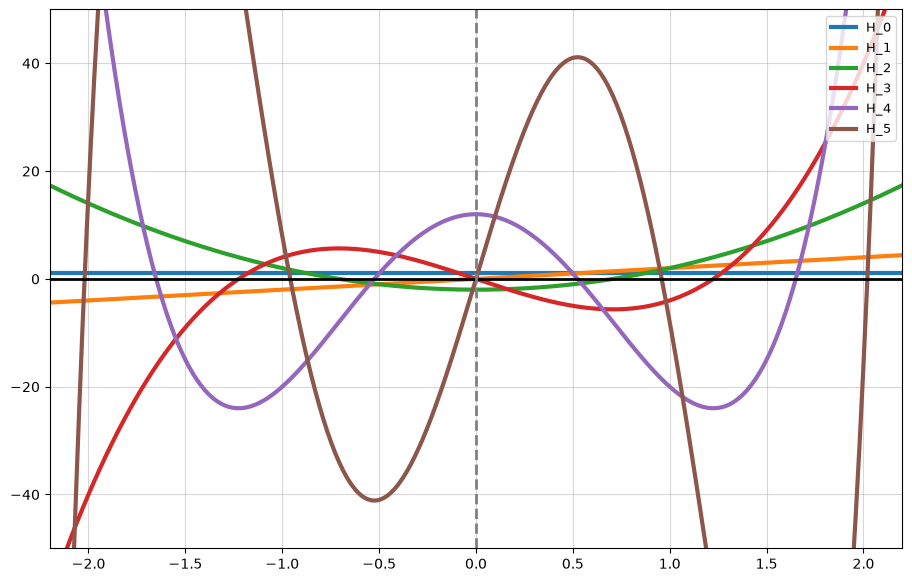

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2.5, 2.5, 500)

H0 = 0 * x + 1
H1 = 2 * x
H2 = 4 * x**2 - 2
H3 = 8 * x**3 - 12 * x
H4 = 16 * x**4 - 48 * x**2 + 12
H5 = 32 * x**5 - 160 * x**3 + 120 * x

fig, axes = plt.subplots(figsize=(11, 7))

axes.plot(x, H0, lw=3, label='H_0')
axes.plot(x, H1, lw=3, label='H_1')
axes.plot(x, H2, lw=3, label='H_2')
axes.plot(x, H3, lw=3, label='H_3')
axes.plot(x, H4, lw=3, label='H_4')
axes.plot(x, H5, lw=3, label='H_5')
axes.axhline(0, lw=2, color='black')
axes.axvline(0, lw=2, ls='--', color='gray')
axes.set_xlim(-2.2, 2.2)
axes.set_ylim(-50, 50)
axes.legend(fontsize=9, loc='upper right')
axes.grid(alpha=0.5)

plt.show()

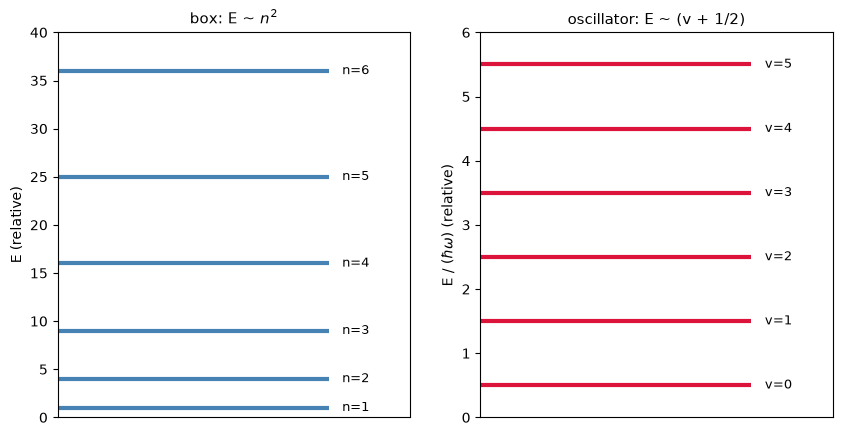

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for n in range(1, 7):
    axes[0].hlines(n**2, 0, 1, lw=3, color="steelblue")
    axes[0].text(1.05, n**2, f"n={n}", va="center", fontsize=9)
for v in range(6):
    axes[1].hlines(v + 0.5, 0, 1, lw=3, color="crimson")
    axes[1].text(1.05, v + 0.5, f"v={v}", va="center", fontsize=9)

axes[0].set_xlim(0, 1.3)
axes[0].set_ylim(0, 40)
axes[0].set_xticks([])
axes[0].set_title("box: E ~ $n^2$", fontsize=11)
axes[0].set_ylabel("E (relative)")
axes[1].set_xlim(0, 1.3)
axes[1].set_ylim(0, 6)
axes[1].set_xticks([])
axes[1].set_title("oscillator: E ~ (v + 1/2)", fontsize=11)
axes[1].set_ylabel("E / ($\\hbar \\omega$) (relative)")
plt.show()

In [3]:
from scipy.constants import hbar, u, e

k = 572  # 수소 분자의 힘 상수 (N/m)
mu = 0.504 * u

omega = np.sqrt(k / mu)

print(f"omega         = {omega:.4e} rad/s")
print(f"hbar * omega  = {hbar * omega / e:.4f} eV")
print(f"영점 에너지    = {0.5 * hbar * omega / e:.4f} eV")

omega         = 8.2672e+14 rad/s
hbar * omega  = 0.5442 eV
영점 에너지    = 0.2721 eV


In [4]:
N, L = 2000, 5e-11
dx = 2 * L / (N + 1)
x = np.linspace(-L, L, N + 2)[1:-1]


def D2(N, dx):
    return (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


def solve(N, L, potential=None):
    V = np.zeros(N) if potential is None else potential(x)
    H = -(hbar**2) / (2 * mu) * D2(N, dx) + np.diag(V)
    E, psi = np.linalg.eigh(H)

    return x, E / e, psi


V_harmonic = lambda x: 0.5 * k * x**2

x, E, psi = solve(N, L, V_harmonic)

print(f"{'v':>2} {'수치해 (eV)':>10} {'해석해 (eV)':>10} {'오차':>8}")
for v in range(6):
    exact = (v + 0.5) * hbar * omega / e
    print(f"{v:2d} {E[v]:12.5f} {exact:12.5f} {abs(E[v]-exact)/exact*100:9.4f}%")

 v   수치해 (eV)   해석해 (eV)       오차
 0      0.27208      0.27208    0.0000%
 1      0.81624      0.81624    0.0005%
 2      1.36047      1.36039    0.0055%
 3      1.90522      1.90455    0.0354%
 4      2.45272      2.44871    0.1640%
 5      3.00994      2.99286    0.5706%


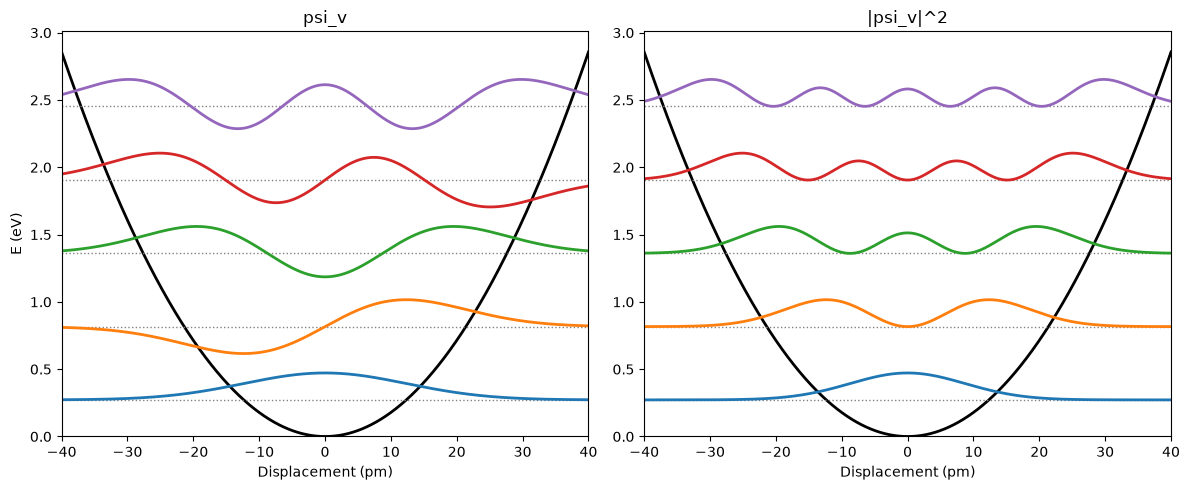

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
V = 0.5 * k * x**2 / e

axes[0].plot(x * 1e12, V, color="black", lw=2)
axes[1].plot(x * 1e12, V, color="black", lw=2)
for v in range(5):
    f = psi[:, v] / np.sqrt(dx)
    if f[np.argmax(np.abs(f))] < 0:
        f = -f
    axes[0].hlines(E[v], -50, 50, color="gray", lw=1, ls=":")
    axes[1].hlines(E[v], -50, 50, color="gray", lw=1, ls=":")
    axes[0].plot(x * 1e12, E[v] + 0.2 * f / np.abs(f).max(), lw=2)
    axes[1].plot(x * 1e12, E[v] + 0.2 * f**2 / np.abs(f**2).max(), lw=2)
axes[0].set_xlim(-40, 40)
axes[0].set_ylim(0, E[5])
axes[0].set_xlabel("Displacement (pm)")
axes[0].set_ylabel("E (eV)")
axes[0].set_title("psi_v")

axes[1].set_xlim(-40, 40)
axes[1].set_ylim(0, E[5])
axes[1].set_xlabel("Displacement (pm)")
axes[1].set_title("|psi_v|^2")

plt.tight_layout()
plt.show()

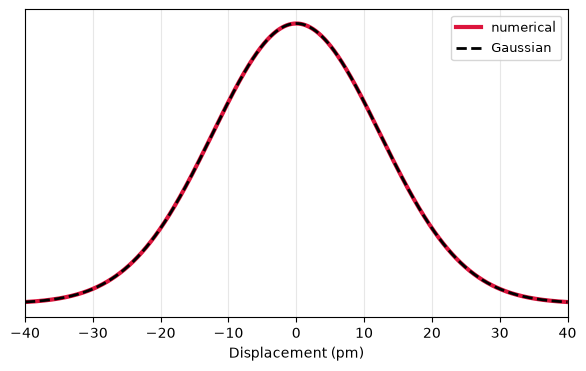

최대 차이: 0.0270%


In [6]:
alpha = mu * omega / hbar

g0 = psi[:, 0] / np.sqrt(dx)
if g0[len(g0) // 2] < 0:
    g0 = -g0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x * 1e12, g0 / g0.max(), color="crimson", lw=3, label="numerical")
ax.plot(
    x * 1e12,
    np.exp(-alpha * x**2 / 2),
    color="black",
    lw=2,
    ls="--",
    label="Gaussian",
)
ax.set_xlim(-40, 40)
ax.set_xlabel("Displacement (pm)")
ax.set_yticks([])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

print(
    f"최대 차이: {np.max(np.abs(g0 / g0.max() - np.exp(-alpha * x**2 / 2))) * 100:.4f}%"
)

In [7]:
for v in range(4):
    p = psi[:, v] / np.sqrt(dx)
    x_mean = np.trapezoid(p * x * p, x)
    x2_mean = np.trapezoid(p * x**2 * p, x)
    p2_mean = np.trapezoid(p * (-(hbar**2) * (D2(N, dx) @ p)), x)
    sx, sp = np.sqrt(x2_mean - x_mean**2), np.sqrt(p2_mean)
    print(f"v={v}: sigma_x sigma_p = {sx*sp/hbar:.5f} hbar")

v=0: sigma_x sigma_p = 0.50000 hbar
v=1: sigma_x sigma_p = 1.50001 hbar
v=2: sigma_x sigma_p = 2.50014 hbar
v=3: sigma_x sigma_p = 3.50121 hbar
